In [1]:
import os
import numpy as np
import torch
from torch_geometric.loader import DataLoader
from preprocessing.data_utils import AtomGraphDataset

d:\ProgramData\Anaconda3\envs\pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def RSE(prediction, target):
    for i in range(int(len(prediction)/100)):
        if i==0:
            loss=torch.sum((target[i*100:(i+1)*100] - prediction[i*100:(i+1)*100])**2)/torch.sum((target[i*100:(i+1)*100])**2)
        else:
            loss+=torch.sum((target[i*100:(i+1)*100] - prediction[i*100:(i+1)*100])**2)/torch.sum((target[i*100:(i+1)*100])**2)
    return loss

In [ ]:
def predict(graph, model,device):

    graph = graph.to(device)
    nodes,edge_sources,edge_targets,edge_distance,mask,combine_sets,plane_wave = graph.x,graph.edge_sources,graph.edge_targets,graph.edge_distance,graph.mask,graph.combine_sets,graph.plane_wave
    batch_seg = torch.tensor(np.repeat(0, nodes.shape[0]), device=device,dtype=torch.int64)

    model.to(device)
    model.eval()
    with torch.no_grad():
        graph_pred = model(nodes,edge_sources,edge_targets,edge_distance,mask,batch_seg,combine_sets,plane_wave)
        graph_pred = graph_pred.cpu().numpy().flatten()
    return graph_pred

In [ ]:
from cgxas.models import CGXAS
device='cpu'

cgnn = CGXAS(
        n_node_feat=146, 
        n_hidden_feat=256,  
        out_feat=100, 
        conv_bias=True, 
        n_GNN=5, 
        n_MLP=5,
        node_activation="Sigmoid", 
        MLP_activation="Elu", 
        use_node_batch_norm=True, 
        use_edge_batch_norm=True, 
        cutoff=8, 
        n_grid_K=4, 
        n_Gaussian=64
        ).to(device)
cgnn.load_state_dict(torch.load('./bestmodel/CGXAS_Exp_S.pt'))

<All keys matched successfully>

In [4]:
test_data = AtomGraphDataset(root='./dataset/Exp_S_test_1.pt')

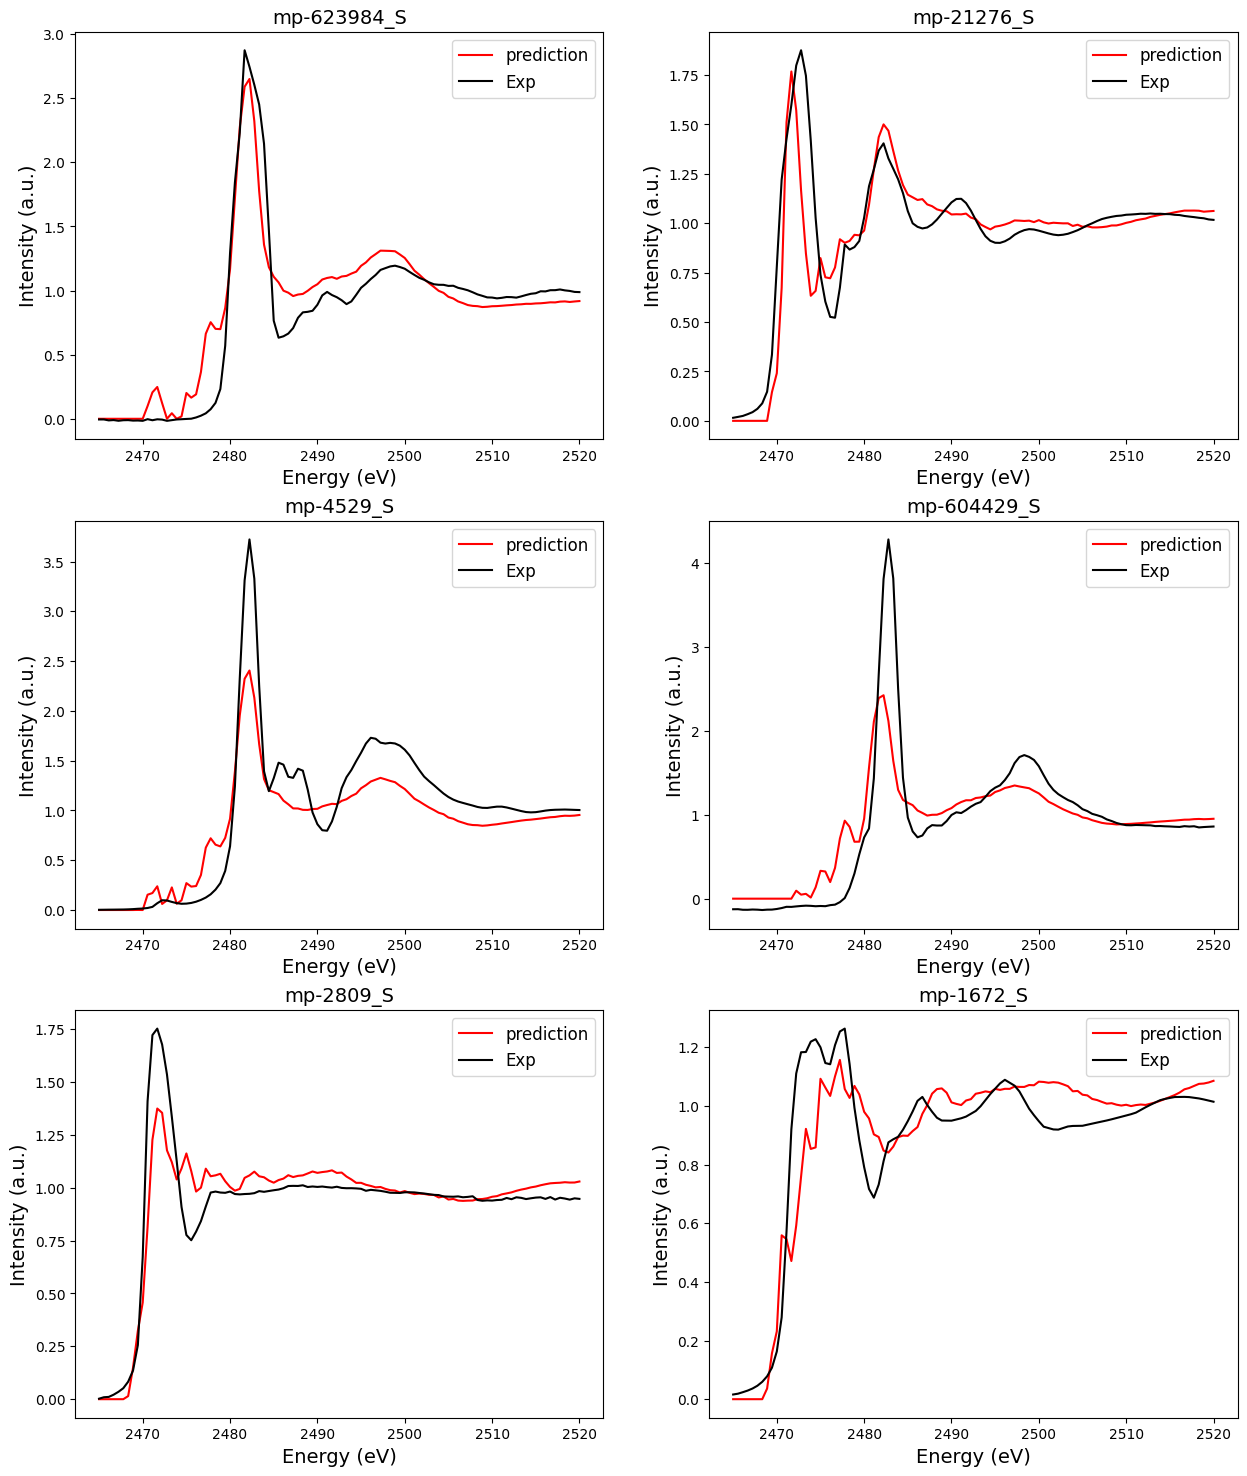

In [ ]:
import matplotlib.pyplot as plt
idxs=[0,1,2,3,4,5]
fig, axis = plt.subplots(3, 2,figsize = (15, 18))
axis = list(axis[:, 0]) + list(axis[:, 1])

for id, ax in zip(idxs, axis):
    pred=predict(test_data[id],cgnn,device)
    ax.plot(test_data[id].spectrum_e, pred, color='r', label='Prediction')
    ax.plot(test_data[id].spectrum_e, test_data[id].spectrum_i, color='blue', label='Exp')
    ax.legend(fontsize='large')
    ax.set_title(test_data[id].name,fontsize=14)
    ax.set_xlabel('Energy (eV)',fontsize=14)
    ax.set_ylabel('Intensity (a.u.)',fontsize=14)  
    